**Vocabulary & Tokenization**

**What’s Happening & Why: You define which words the model “knows” You convert words into IDs that the model can work withThink of this like: words → numbers → math!**

In [ ]:
import numpy as np

In [ ]:
# vocabulary
vocab = ["<pad>", "<unk>", "<bos>", "<eos>", "i", "love", "learning", "transformers", "are", "cool", "."]
vocab_size = len(vocab)

In [ ]:
#  mappings: word <-> id
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}


**Word Embeddings**

**What’s Happening & Why: Words are turned into 8D vectors (randomly for now)
These vectors represent the meaning of each word You now have a numerical representation of the sentence**

In [ ]:
# tokenizer
def tokenize(text):
    return [word2idx.get(w, word2idx["<unk>"]) for w in text.lower().split()]

def detokenize(indices):
    return " ".join([idx2word.get(i, "<unk>") for i in indices])

# Initialize word embeddings randomly
embedding_dim = 8
embeddings = np.random.randn(vocab_size, embedding_dim)

In [ ]:
text = "<bos> i love learning transformers ."
tokens = tokenize(text)
print("Tokenized:", tokens)
print("Word embeddings shape:", embeddings.shape)
print("First embedded word:", embeddings[tokens[0]])

Tokenized: [2, 4, 5, 6, 7, 10]
Word embeddings shape: (11, 8)
First embedded word: [ 9.24509462e-01 -5.44208576e-02 -2.55281995e+00  5.45343241e-04
 -1.33792257e+00 -9.63599050e-01 -8.23448912e-01  1.51712438e+00]


In [ ]:
# Print all word embeddings with word labels
for word, idx in word2idx.items():
    print(f"{word:>12} → {embeddings[idx]}")


       <pad> → [ 2.27688876  0.7157275  -0.25514368  0.26670209 -1.65841958  0.04715956
  0.86453321 -0.77238876]
       <unk> → [ 0.05705571 -0.02103835  0.00467315 -1.46513251 -1.54737155  0.38953367
  1.07517461 -0.05028323]
       <bos> → [ 9.24509462e-01 -5.44208576e-02 -2.55281995e+00  5.45343241e-04
 -1.33792257e+00 -9.63599050e-01 -8.23448912e-01  1.51712438e+00]
       <eos> → [ 0.22755381  0.47236479 -0.45918213 -1.57347112  0.53404385 -1.04462143
  1.93933676 -1.64920772]
           i → [ 1.0774902  -0.14499189 -0.59604252  0.09804096  1.56621541  0.54270862
  0.0915083   2.04271437]
        love → [ 0.12226192 -1.48446403  2.620583   -0.44574493 -0.21071949  0.78210669
  0.26930874  0.06162677]
    learning → [-0.58620669 -0.14790329  0.06874403  0.24977687 -0.36174735  0.23086222
 -0.9495656  -0.39593013]
transformers → [ 0.11693506 -0.61607025  1.61689126 -0.55271443  0.30090767  0.28082314
 -3.09122327  1.17972546]
         are → [-0.52421056 -0.1629734   0.12490654 -1.5

**Positional Encoding**

**Transformers don’t know word order unless we tell them! Positional encodings give each word a sense of where it is in the sentence Now  model knows: “i comes before love comes before learning”**

In [ ]:
import math

In [ ]:
# Function to generate positional encodings
def get_positional_encoding(seq_len, embed_dim):
    positional_encodings = np.zeros((seq_len, embed_dim))

    for pos in range(seq_len):
        for i in range(0, embed_dim, 2):
            positional_encodings[pos, i] = np.sin(pos / (10000 ** (i / embed_dim)))
            positional_encodings[pos, i+1] = np.cos(pos / (10000 ** (i / embed_dim)))

    return positional_encodings

In [ ]:
# Adding positional encoding to the word embeddings
def add_positional_encoding(embeddings, seq_len):
    pos_encodings = get_positional_encoding(seq_len, embeddings.shape[1])
    return embeddings + pos_encodings


In [ ]:
# Add positional encodings to our sentence embeddings
seq_len = len(tokens)  # Number of words in the sentence
embeddings_with_pe = add_positional_encoding(embeddings[tokens], seq_len)

In [ ]:
print("Embedding with Positional Encoding (Only Sentence Tokens):")
for i, token_id in enumerate(tokens):
    word = idx2word[token_id]
    print(f"{word:>12} → {embeddings_with_pe[i]}")

Embedding with Positional Encoding (Only Sentence Tokens):
       <bos> → [ 0.92450946  0.94557914 -2.55281995  1.00054534 -1.33792257  0.03640095
 -0.82344891  2.51712438]
           i → [ 1.91896119  0.39531041 -0.49620911  1.09304513  1.57621524  1.54265862
  0.0925083   3.04271387]
        love → [ 1.03155935 -1.90061087  2.81925233  0.53432165 -0.19072083  1.78190669
  0.27130874  1.06162477]
    learning → [-0.44508668 -1.13789579  0.36426424  1.20511336 -0.33175185  1.23041226
 -0.9465656   0.60406537]
transformers → [-0.63986744 -1.26971387  2.0063096   0.36834657  0.340897    1.28002325
 -3.08722328  2.17971746]
           . → [-0.2970037   2.63164624  0.17186127  1.86501911  0.41764841 -0.39770341
  0.54213853  0.07172684]


**Project to Q, K, V Vectors**

For each word, we make 3 versions:

Query → "What am I looking for?"

Key → "What information do I have?"

Value → "What do I send if chosen?"

These projections allow the model to compare words in a learnable way

In [ ]:
# Dimensions
embed_dim = embeddings_with_pe.shape[1]  # still 8

# Initialize weight matrices randomly for Q, K, V (like mini neural networks)
W_Q = np.random.randn(embed_dim, embed_dim)
W_K = np.random.randn(embed_dim, embed_dim)
W_V = np.random.randn(embed_dim, embed_dim)

# Project input embeddings to Q, K, V
Q = embeddings_with_pe @ W_Q
K = embeddings_with_pe @ W_K
V = embeddings_with_pe @ W_V

print("Shapes:")
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)


Shapes:
Q: (6, 8)
K: (6, 8)
V: (6, 8)


In [ ]:
for i, token_id in enumerate(tokens):
    word = idx2word[token_id]
    print(f"{word:>12} | Q: {Q[i]} | K: {K[i]} | V: {V[i]}")


       <bos> | Q: [ 3.38739883  3.41242735  0.62836123 -2.31615966 -3.1371388   0.49865762
 -1.02268554  3.04076988] | K: [ 6.29357636  2.12490243  3.90515697  3.97944284  0.41283102 -4.2243381
 -0.19679187 -5.02462319] | V: [-3.62642866 -3.76941649  6.88719294 -4.54578776  6.86181966  5.73364334
  4.15485971 -0.44902787]
           i | Q: [ 0.95501048 -2.56224236 -7.25355292  5.30859717  8.19963912 -3.31498287
  1.85563145  3.96326545] | K: [-0.1274515   0.66586535 10.4050162  -8.38312808 -2.03873724 -5.43824064
 -8.06315658  1.4982092 ] | V: [ -0.50676517  -4.54358813  -0.70779679 -14.72390913   2.67070405
   0.9133148   11.20650976   3.37701426]
        love | Q: [ 1.62578369  0.00933906 -7.69993265  4.82501172  5.69233645 -4.45266844
  2.52944299  1.61929611] | K: [ -3.17043692   2.35175364   5.15224118 -11.67837807   0.97187661
   0.27631632  -3.52932323   5.02310952] | V: [-0.17928503  0.88240497 -7.99862328 -3.01900793 -2.67223667 -4.37438032
  7.18232491  0.62931364]
    learni

**Attention Mechanism**

Each word uses its Query to check all Keys from other words

It scores how relevant they are → applies softmax → gets weights

Uses those weights to gather info from Value vectors

The output is a context-aware version of the sentence

In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)


In [ ]:
# Scaled Dot-Product Attention
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    attention_weights = softmax(scores)
    output = np.dot(attention_weights, V)
    return output, attention_weights

In [ ]:
# Use our sentence's embeddings with positional encodings
X = embeddings_with_pe  # shape: (seq_len, embed_dim)

# For simplicity: Q = K = V = X (self-attention!)
Q = K = V = X

# Apply attention
attn_output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output (New word representations):\n")
for i in range(len(tokens)):
    word = idx2word[tokens[i]]
    print(f"{word:>12} → {attn_output[i]}")


Attention Output (New word representations):

       <bos> → [ 0.96636863  0.91099717 -2.40883501  1.00823063 -1.16427687  0.12353015
 -0.77282735  2.5290476 ]
           i → [ 1.83948803  0.37946002 -0.50928147  1.08020617  1.44059132  1.48457519
  0.02931694  2.98461862]
        love → [ 0.8504561  -1.78311908  2.63930789  0.53779815 -0.10944921  1.71617471
 -0.09624943  1.20192814]
    learning → [-0.03540538 -1.11571915  1.47242239  0.65583431  0.1215982   1.31371499
 -1.66377826  1.70037819]
transformers → [-0.59374916 -1.27366026  1.99783668  0.38152073  0.32854595  1.29000968
 -2.98844241  2.14783168]
           . → [-0.13754543  2.38242665  0.03404918  1.7722621   0.37890115 -0.25868386
  0.42767709  0.33797952]


**Visualize Attention Weights**

You can now see how the model focuses on other words

Example: transformers might focus on learning and love

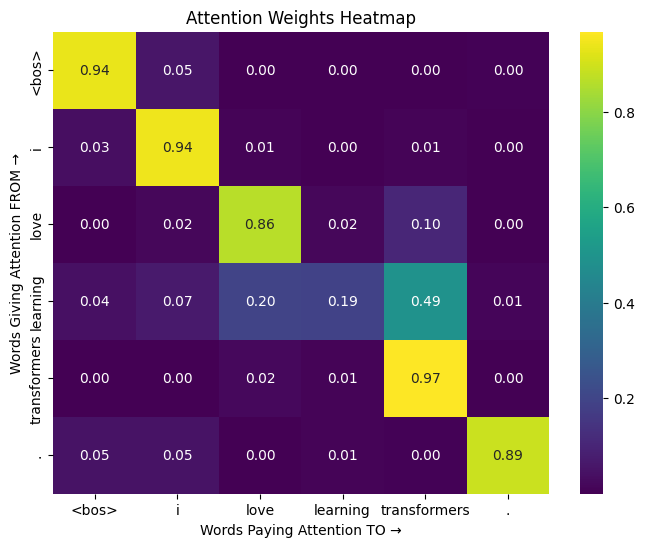

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights,
            xticklabels=[idx2word[t] for t in tokens],
            yticklabels=[idx2word[t] for t in tokens],
            cmap="viridis", annot=True, fmt=".2f")

plt.title("Attention Weights Heatmap")
plt.xlabel("Words Paying Attention TO →")
plt.ylabel("Words Giving Attention FROM →")
plt.show()


**FEEDFORWARD**

In [ ]:
# Feedforward layer: Linear + ReLU + Linear
hidden_dim = 16

# Initialize weights
W1 = np.random.randn(embedding_dim, hidden_dim)
b1 = np.zeros(hidden_dim)

W2 = np.random.randn(hidden_dim, vocab_size)
b2 = np.zeros(vocab_size)

# ReLU activation
def relu(x):
    return np.maximum(0, x)

# Forward pass through feedforward layer
def feedforward(x):
    x = relu(x @ W1 + b1)
    logits = x @ W2 + b2
    return logits


In [ ]:
# Use last attention output to predict next word
last_output = attn_output[-1]  # The output of last word "."
logits = feedforward(last_output)

# Softmax to get probabilities
probs = softmax(logits)

# 🗣️ Pick top predicted word
predicted_token = np.argmax(probs)
predicted_word = idx2word[predicted_token]

print("Predicted Next Word:", predicted_word)


Predicted Next Word: are


In [ ]:
# 🔁 Predict multiple next words by feeding output back into model
def predict_next_words(start_text, num_predictions=3):
    current_text = start_text

    for _ in range(num_predictions):
        tokens = tokenize(current_text)
        embedded_tokens = embeddings[tokens]
        seq_len = len(tokens)
        embeddings_with_pe = add_positional_encoding(embedded_tokens, seq_len)

        # Q, K, V
        Q = embeddings_with_pe @ W_Q
        K = embeddings_with_pe @ W_K
        V = embeddings_with_pe @ W_V

        # Attention
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V)

        # Feedforward on last output
        last_output = attn_output[-1]
        logits = feedforward(last_output)
        probs = softmax(logits)

        # Pick top word
        next_token = np.argmax(probs)
        next_word = idx2word[next_token]

        # Append to sentence
        current_text += " " + next_word

    return current_text


In [ ]:
# Start with your original sentence
start_sentence = "<bos> i love learning transformers ."
generated = predict_next_words(start_sentence, num_predictions=3)

print("Original Sentence:", start_sentence)
print(" Predicted Continuation:", generated)


Original Sentence: <bos> i love learning transformers .
 Predicted Continuation: <bos> i love learning transformers . i i i


***TRAINING ON NEW DATA***

In [ ]:
# training dataset
sentences = [
    "<bos> i love transformers . <eos>",
    "<bos> transformers are powerful . <eos>",
    "<bos> i am learning transformers . <eos>",
    "<bos> transformers love attention . <eos>",
    "<bos> attention is powerful . <eos>",
    "<bos> deep learning is fun . <eos>",  # new sentence
    "<bos> neural networks are cool . <eos>",  # new sentence
    "<bos> self-attention improves performance . <eos>",  # new sentence
    "<bos> i enjoy coding with transformers . <eos>",  # new sentence
]


# Tokenize each sentence into word indices
tokenized_sentences = [tokenize(s) for s in sentences]


In [ ]:
# Cell 1: Initialization

import numpy as np

# Initialize word embeddings (size: vocab_size x embedding_dim)
vocab_size = 22  # Total number of words in your vocabulary
embedding_dim = 8  # Embedding size
embeddings = np.random.randn(vocab_size, embedding_dim)

# Initialize weight matrices for Q, K, V (size: embedding_dim x embedding_dim)
W_Q = np.random.randn(embedding_dim, embedding_dim)
W_K = np.random.randn(embedding_dim, embedding_dim)
W_V = np.random.randn(embedding_dim, embedding_dim)

# Initialize weights for the feedforward network
W1 = np.random.randn(embedding_dim, embedding_dim)  # First layer
b1 = np.zeros(embedding_dim)  # Bias for first layer
W2 = np.random.randn(embedding_dim, vocab_size)  # Second layer (output layer)
b2 = np.zeros(vocab_size)  # Bias for second layer

# Vocabulary (map words to indices, including <bos>, <eos>, and <unk>)
vocab = {
    '<bos>': 0,
    'i': 1,
    'love': 2,
    'transformers': 3,
    '.': 4,
    '<eos>': 5,
    'are': 6,
    'powerful': 7,
    'am': 8,
    'learning': 9,
    'attention': 10,
    'is': 11,
    'deep': 12,
    'neural': 13,
    'networks': 14,
    'cool': 15,
    'self-attention': 16,
    'improves': 17,
    'performance': 18,
    'enjoy': 19,
    'coding': 20,
    'with': 21
}

# Reverse vocab for prediction
idx2word = {v: k for k, v in vocab.items()}

# Tokenize function (maps sentence to token indices based on vocab)
def tokenize(sentence):
    return [vocab[word] for word in sentence.split()]

# Example sentence to tokenize
sentence = "<bos> i love transformers . <eos>"
tokens = tokenize(sentence)
print("Tokens:", tokens)


Tokens: [0, 1, 2, 3, 4, 5]


In [ ]:
# Create input-output word pairs
X_train = []
Y_train = []

for tokens in tokenized_sentences:
    for i in range(1, len(tokens)):
        X_train.append(tokens[:i])        # context: [<bos>, i]
        Y_train.append(tokens[i])         # target: next word


In [ ]:
import numpy as np

# Hyperparameters
lr = 0.01
epochs = 1000

In [ ]:
# Helper: softmax + cross-entropy loss
def cross_entropy_loss(pred_probs, true_idx):
    return -np.log(pred_probs[true_idx] + 1e-9)

def cross_entropy_grad(pred_probs, true_idx):
    grad = pred_probs.copy()
    grad[true_idx] -= 1
    return grad

In [ ]:
# Training loop
for epoch in range(epochs):
    total_loss = 0

    for x_seq, y_true in zip(X_train, Y_train):
        seq_len = len(x_seq)
        x_embed = embeddings[x_seq]
        x_embed = add_positional_encoding(x_embed, seq_len)

        # Q, K, V
        Q = x_embed @ W_Q
        K = x_embed @ W_K
        V = x_embed @ W_V

        # Attention
        attn_output, _ = scaled_dot_product_attention(Q, K, V)

        # Feedforward on last word
        last_output = attn_output[-1]
        h = relu(last_output @ W1 + b1)
        logits = h @ W2 + b2
        probs = softmax(logits)

        # Compute loss
        loss = cross_entropy_loss(probs, y_true)
        total_loss += loss

        # Backprop (manual gradient descent — for learning)
        grad_logits = cross_entropy_grad(probs, y_true)

        # Backprop through W2, W1
        dW2 = np.outer(h, grad_logits)
        db2 = grad_logits

        dh = grad_logits @ W2.T
        dh[h <= 0] = 0  # ReLU backprop

        dW1 = np.outer(last_output, dh)
        db1 = dh

        # Update weights
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 10 | Loss: 107.2386
Epoch 20 | Loss: 82.6340
Epoch 30 | Loss: 75.3615
Epoch 40 | Loss: 71.1694
Epoch 50 | Loss: 68.7401
Epoch 60 | Loss: 67.1030
Epoch 70 | Loss: 66.0561
Epoch 80 | Loss: 65.0613
Epoch 90 | Loss: 64.3459
Epoch 100 | Loss: 63.5260
Epoch 110 | Loss: 63.4473
Epoch 120 | Loss: 62.8410
Epoch 130 | Loss: 62.4171
Epoch 140 | Loss: 62.1468
Epoch 150 | Loss: 61.7882
Epoch 160 | Loss: 61.4254
Epoch 170 | Loss: 60.9843
Epoch 180 | Loss: 60.9769
Epoch 190 | Loss: 60.7580
Epoch 200 | Loss: 60.8054
Epoch 210 | Loss: 60.1732
Epoch 220 | Loss: 60.2433
Epoch 230 | Loss: 60.0799
Epoch 240 | Loss: 59.7095
Epoch 250 | Loss: 59.7977
Epoch 260 | Loss: 59.6806
Epoch 270 | Loss: 59.5664
Epoch 280 | Loss: 59.5207
Epoch 290 | Loss: 59.3599
Epoch 300 | Loss: 59.2985
Epoch 310 | Loss: 59.1911
Epoch 320 | Loss: 59.1145
Epoch 330 | Loss: 59.0413
Epoch 340 | Loss: 58.9846
Epoch 350 | Loss: 58.9031
Epoch 360 | Loss: 58.8329
Epoch 370 | Loss: 58.8268
Epoch 380 | Loss: 58.6927
Epoch 390 | Loss: 58

In [ ]:
# Define a function to predict the next word given an input sentence
def predict_next_word(input_sentence):
    tokens = tokenize(input_sentence)  # Tokenize the sentence
    seq_len = len(tokens)

    # Get the word embeddings and add positional encoding
    x_embed = embeddings[tokens]
    x_embed = add_positional_encoding(x_embed, seq_len)

    # Compute Q, K, V
    Q = x_embed @ W_Q
    K = x_embed @ W_K
    V = x_embed @ W_V

    # Attention mechanism
    attn_output, _ = scaled_dot_product_attention(Q, K, V)

    # Feedforward on the last word of the attention output
    last_output = attn_output[-1]
    h = relu(last_output @ W1 + b1)
    logits = h @ W2 + b2
    probs = softmax(logits)

    # Predict the next word by selecting the word with the highest probability
    predicted_token = np.argmax(probs)
    predicted_word = idx2word[predicted_token]

    return predicted_word

# Example input
input_sentence = "<bos> transformers are powerful "
predicted_word = predict_next_word(input_sentence)
print(f"Predicted Next Word: {predicted_word}")


Predicted Next Word: i


In [ ]:
# Generate sentence function
def generate_sentence(start_sentence, max_words=10):
    current_sentence = start_sentence
    for _ in range(max_words):
        next_word = predict_next_word(current_sentence)

        # Stop if the model generates <eos> token
        if next_word == "<eos>":
            break

        current_sentence += " " + next_word

    return current_sentence

# Example usage:
start_sentence = "<bos> transformers are"
generated_sentence = generate_sentence(start_sentence)
print(f"Generated Sentence: {generated_sentence}")


Generated Sentence: <bos> transformers are i attention transformers transformers powerful powerful i i attention transformers


**Percentages of next predicted word**

In [ ]:
def predict_next_word_with_probs(input_sentence):
    tokens = tokenize(input_sentence)  # Tokenize the sentence
    seq_len = len(tokens)

    # Get the word embeddings and add positional encoding
    x_embed = embeddings[tokens]
    x_embed = add_positional_encoding(x_embed, seq_len)

    # Compute Q, K, V
    Q = x_embed @ W_Q
    K = x_embed @ W_K
    V = x_embed @ W_V

    # Attention mechanism
    attn_output, _ = scaled_dot_product_attention(Q, K, V)

    # Feedforward on the last word of the attention output
    last_output = attn_output[-1]
    h = relu(last_output @ W1 + b1)
    logits = h @ W2 + b2
    probs = softmax(logits)

    # Predict the next word by selecting the word with the highest probability
    predicted_token = np.argmax(probs)
    predicted_word = idx2word[predicted_token]

    # Display probabilities as percentages for all words
    print("\nPredicted Probabilities:")
    for idx, prob in enumerate(probs):
        word = idx2word[idx]
        print(f"{word:15s}: {prob * 100:.2f}%")

    return predicted_word


In [ ]:
input_sentence = "<bos> transformers are powerful"
predicted_word = predict_next_word_with_probs(input_sentence)
print(f"\nPredicted Next Word: {predicted_word}")



Predicted Probabilities:
<bos>          : 0.00%
i              : 84.59%
love           : 0.00%
transformers   : 0.00%
.              : 0.00%
<eos>          : 0.00%
are            : 15.40%
powerful       : 0.00%
am             : 0.00%
learning       : 0.00%
attention      : 0.00%
is             : 0.00%
deep           : 0.00%
neural         : 0.00%
networks       : 0.00%
cool           : 0.00%
self-attention : 0.00%
improves       : 0.00%
performance    : 0.00%
enjoy          : 0.00%
coding         : 0.00%
with           : 0.00%

Predicted Next Word: i
